In [3]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit


In [4]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [5]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


In [9]:
def hybrid_ernn_loss(y, e_hybrid, sigma, tau):
    """
    Hybrid ERNN AGD NLL Loss
    y        : observed returns (tensor), shape (T,)
    e_hybrid : hybrid expectile estimate (tensor), shape (T,)
               = psi * CARE_component + (1-psi) * FNN_component
    sigma    : scale parameter (scalar)
    tau      : expectile level in (0,1)
    """
    diff = y - e_hybrid
    omega = torch.abs(tau - (diff < 0).float()) * diff**2
    nll = (torch.log(sigma)
           + torch.log(torch.sqrt(torch.tensor(torch.pi / tau))
                       + torch.sqrt(torch.tensor(torch.pi / (1 - tau))))
           - torch.log(torch.tensor(2.0))
           + omega / sigma**2)
    return nll.mean()
    
def compute_hybrid_location_cross_a(y, X, gamma1, gamma2, gamma3, fnn_model, psi):
    """
    Cross-lagged hybrid ERNN location -- A (asymmetric) functional form.
    The CARE component uses the previous hybrid output as its autoregressive input.
    A form: e_t = gamma1 * e_{t-1}^H + gamma2 * y_{t-1}^+ + gamma3 * y_{t-1}^-
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)

    e_care_list   = [torch.zeros(1)]
    e_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        y_pos  = torch.clamp(y[t-1],  min=0)   # y^+
        y_neg  = torch.clamp(-y[t-1], min=0)   # y^-
        care_t = (gamma1 * e_hybrid_list[t-1]
                + gamma2 * y_pos
                + gamma3 * y_neg)
        e_care_list.append(care_t)

        hybrid_t = psi * care_t + (1 - psi) * fnn_out[t]
        e_hybrid_list.append(hybrid_t)

    e_care   = torch.stack(e_care_list).squeeze(-1)
    e_hybrid = torch.stack(e_hybrid_list).squeeze(-1)

    return e_hybrid, e_care

In [11]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

# Tuning

In [13]:
class HybridERNN_A(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.gamma1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.gamma2_raw = nn.Parameter(torch.tensor(0.3))     # y^+ impact
        self.gamma3_raw = nn.Parameter(torch.tensor(0.3))     # y^- impact
        self.psi_raw    = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw  = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        gamma1 = torch.sigmoid(self.gamma1_raw)
        gamma2 = torch.nn.functional.softplus(self.gamma2_raw)
        gamma3 = torch.nn.functional.softplus(self.gamma3_raw)
        psi    = torch.sigmoid(self.psi_raw)
        sigma  = torch.nn.functional.softplus(self.sigma_raw)

        # cross-lagged A: uses previous hybrid output
        e_hybrid, e_care = compute_hybrid_location_cross_a(
            y, X, gamma1, gamma2, gamma3, self.fnn, psi)

        return e_hybrid, sigma


def compute_crp(y, q, alpha):
    """
    Coverage Ratio Penalty (CRP).
    For alpha <= 0.5: count violations where y <= q (lower tail).
    For alpha >  0.5: count violations where y >  q (upper tail).
    CRP = empirical_coverage / alpha*
    Penalty = (CRP - 1)^2
    """
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective(trial, tau):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridERNN_A(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        crp, crp_penalty = compute_crp(y_val, e_val, tau)

        gamma1 = torch.sigmoid(model.gamma1_raw).item()
        gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        gamma3 = torch.nn.functional.softplus(model.gamma3_raw).item()
        psi    = torch.sigmoid(model.psi_raw).item()
        sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('gamma1',      gamma1)
    trial.set_user_attr('gamma2',      gamma2)
    trial.set_user_attr('gamma3',      gamma3)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"tau={tau} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"gamma1={gamma1:.4f} | gamma2={gamma2:.4f} | gamma3={gamma3:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    for rank, t in enumerate(sorted(trials, key=lambda t: t._nll), start=1):
        t._rank_nll = rank

    for rank, t in enumerate(sorted(trials, key=lambda t: t._crp_penalty), start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each tau level
# -------------------------
tau_levels              = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed               = 2026
best_configs_ernn_a_cross = {}  # distinct name for ERNN A cross-lagged

for i, tau in enumerate(tau_levels):
    print(f"\n{'='*60}")
    print(f"Tuning ERNN A Cross-lagged for tau = {tau} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, t=tau: objective(trial, tau=t),
                   n_trials=200, show_progress_bar=True)

    best_trial, all_trials = select_best_trial_by_rank(study)

    print(f"\nRanking summary for tau={tau}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'tau':         tau,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'gamma1':      t.user_attrs['gamma1'],
            'gamma2':      t.user_attrs['gamma2'],
            'gamma3':      t.user_attrs['gamma3'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'ernn_a_cross_ranking_tau_{tau}.csv', index=False)
    print(f"  Full ranking saved to ernn_a_cross_ranking_tau_{tau}.csv")

    best_configs_ernn_a_cross[tau] = best_trial.params.copy()
    best_configs_ernn_a_cross[tau]['tau'] = tau

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridERNN_A(X_train.shape[1], best_configs_ernn_a_cross[tau])

    if best_configs_ernn_a_cross[tau]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_ernn_a_cross[tau]['lr'],
                                     weight_decay=best_configs_ernn_a_cross[tau]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_ernn_a_cross[tau]['lr'],
                                      weight_decay=best_configs_ernn_a_cross[tau]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_ernn_a_cross[tau]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            e_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_ernn_a_cross[tau].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_ernn_loss(y_val, e_val_final, sigma_val_final, tau).item()
        final_crp, final_crp_penalty = compute_crp(y_val, e_val_final, tau)

        est_gamma1 = torch.sigmoid(best_model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(best_model.gamma2_raw).item()
        est_gamma3 = torch.nn.functional.softplus(best_model.gamma3_raw).item()
        est_psi    = torch.sigmoid(best_model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_ernn_a_cross[tau]['est_psi']    = est_psi
    best_configs_ernn_a_cross[tau]['est_sigma']  = est_sigma
    best_configs_ernn_a_cross[tau]['est_gamma1'] = est_gamma1
    best_configs_ernn_a_cross[tau]['est_gamma2'] = est_gamma2
    best_configs_ernn_a_cross[tau]['est_gamma3'] = est_gamma3
    best_configs_ernn_a_cross[tau]['est_crp']    = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank: {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:    {est_psi:.4f}")
    print(f"Estimated sigma:  {est_sigma:.4f}")
    print(f"Estimated gamma1: {est_gamma1:.4f}")
    print(f"Estimated gamma2: {est_gamma2:.4f}")
    print(f"Estimated gamma3: {est_gamma3:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE -- ERNN A CROSS-LAGGED")
print("="*60)
for tau, config in best_configs_ernn_a_cross.items():
    print(f"tau={tau}: {config}")

[I 2026-07-13 22:42:48,258] A new study created in memory with name: no-name-54264b09-db16-4366-b4e6-79c674d3e84a



Tuning ERNN A Cross-lagged for tau = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=1.7620 | CRP=0.0883 | CRP_penalty=0.8312 | tau=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5222 | sigma=0.8937 | gamma1=0.7856 | gamma2=0.8121 | gamma3=0.8075
[I 2026-07-13 22:43:06,467] Trial 0 finished with value: 1.7619874477386475 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 1.7619874477386475.
  Trial 1: NLL=1.7816 | CRP=0.0883 | CRP_penalty=0.8312 | tau=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5131 | sigma=0.9125 | gamma1=0.7931 | gamma2=0.8391 | gamma3=0.8440
[I 2026-07-13 22:43:23,667] Trial 1 finished with value: 1.7816153764724731 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'laye

[I 2026-07-13 23:43:57,886] A new study created in memory with name: no-name-0d5263c5-e09b-45b5-a909-342ad4d819e5


...

  Trial 0: NLL=0.4156 | CRP=0.5740 | CRP_penalty=0.1815 | tau=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5203 | sigma=0.3105 | gamma1=0.7833 | gamma2=0.7347 | gamma3=0.7702
[I 2026-07-14 11:35:59,307] Trial 0 finished with value: 0.4155946373939514 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 0.4155946373939514.
  Trial 1: NLL=0.7105 | CRP=4.3267 | CRP_penalty=11.0670 | tau=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5227 | sigma=0.4174 | gamma1=0.7821 | gamma2=0.7880 | gamma3=0.8165
[I 2026-07-14 11:36:19,114] Trial 1 finished with value: 0.7104796767234802 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout':

[I 2026-07-14 12:36:19,689] A new study created in memory with name: no-name-749e9635-4776-460f-ac73-d7e254a56bb2



Best trial (rank-based): #112
  NLL rank: 36 | CRP rank: 20 | Sum: 56
Final NLL:          -2.3984
Final CRP:          1.3687
Final CRP penalty:  0.1359
Best params: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.014271405326772964, 'layernorm': False, 'weight_init': 'he', 'lr': 0.043732733642846626, 'optimizer': 'adamw', 'batch_size': 128, 'weight_decay': 1.2326547241159089e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 81}
Estimated psi:    0.8961
Estimated sigma:  0.0151
Estimated gamma1: 0.0991
Estimated gamma2: 0.0617
Estimated gamma3: 0.1262

Tuning ERNN A Cross-lagged for tau = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=0.6296 | CRP=8.3885 | CRP_penalty=54.5902 | tau=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5179 | sigma=0.2883 | gamma1=0.7829 | gamma2=0.6822 | gamma3=0.7203
[I 2026-07-14 12:36:40,962] Trial 0 finished with value: 0.6296499967575073 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 0.6296499967575073.
  Trial 1: NLL=1.8327 | CRP=4.9448 | CRP_penalty=15.5615 | tau=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5026 | sigma=0.9599 | gamma1=0.7987 | gamma2=0.8564 | gamma3=0.8579
[I 2026-07-14 12:37:00,403] Trial 1 finished with value: 1.8326568603515625 and parameters: {'n_hidden_layers': 1, 'activation':


Training final model for tau = 0.025 (A cross-lagged)
  Epoch 50: train=0.2679, val=0.2291
  Epoch 100: train=-1.4507, val=-1.5188
  Epoch 150: train=-1.9742, val=-2.0192
  Epoch 200: train=-2.0883, val=-2.3386
  Test loss: -2.4270 | gamma1=0.0454 | gamma2=0.0577 | gamma3=0.1986 | psi=0.8801 | sigma=0.0118

Training final model for tau = 0.05 (A cross-lagged)
  Epoch 50: train=-0.2109, val=-0.2724
  Epoch 100: train=-1.5126, val=-1.2200
  Epoch 150: train=-1.8570, val=-1.9013
  Epoch 200: train=-2.0113, val=-1.9317
  Test loss: -2.4450 | gamma1=0.0499 | gamma2=0.0304 | gamma3=0.1703 | psi=0.9803 | sigma=0.0149

Training final model for tau = 0.25 (A cross-lagged)
  Epoch 50: train=-0.5882, val=-0.6446
  Epoch 100: train=-1.8847, val=-1.8757
  Epoch 150: train=-2.2739, val=-2.3263
  Epoch 200: train=-2.3953, val=-2.4901
  Test loss: -2.5809 | gamma1=0.0517 | gamma2=0.0590 | gamma3=0.1826 | psi=0.9453 | sigma=0.0213

Training final model for tau = 0.5 (A cross-lagged)
  Epoch 50: train=

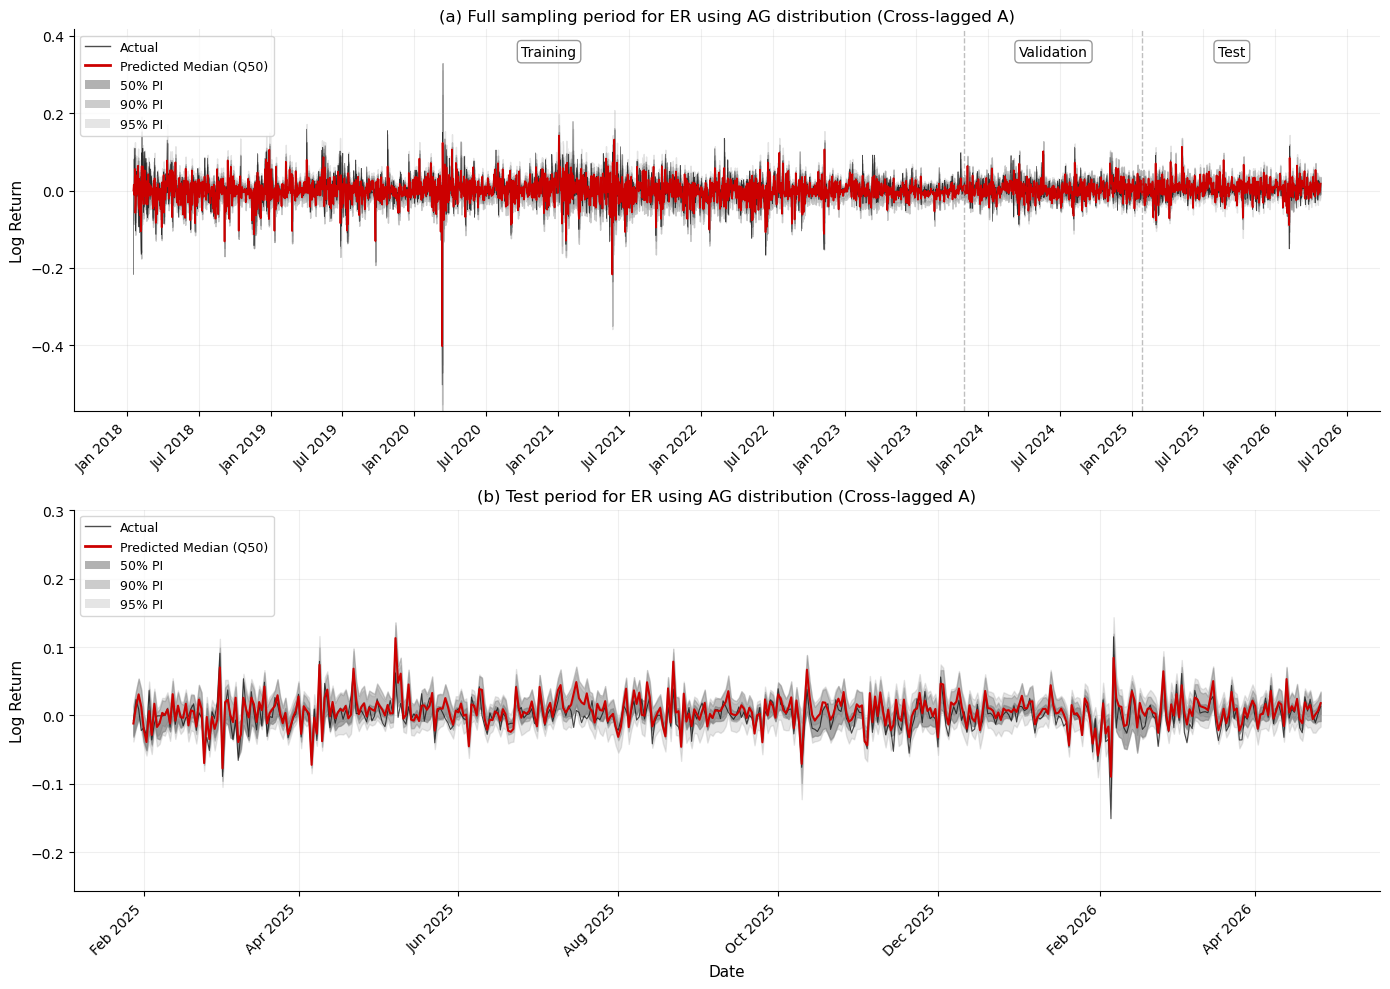

Full period plot saved to hybrid_ernn_cross_a_predictions_full.png
Test period plot saved to hybrid_ernn_cross_a_predictions_test.png

CROSSOVER ANALYSIS -- ERNN Cross A (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):           1      0.22% <-- TAIL
  (0.050, 0.250):         247     54.41%
  (0.250, 0.500):          46     10.13%
  (0.500, 0.750):          81     17.84%
  (0.750, 0.950):          11      2.42%
  (0.950, 0.975):         101     22.25% <-- TAIL
  ------------------------------------------
  Total violations:         487  (17.88% of all pairs)
  Tail violations:          102  (11.23% of tail pairs)

TEST SET METRICS -- ERNN A Cross-lagged
     tau        NLL            ASE
  ----------------------------------
   0.025    -2.4270       0.000020
    0.05    -2.4450       0.000040
    0.25    -2.5809       0.000109
     0.5    -2.6803       0.000105
    0.75    -2.6450       0.000086
    0.95    -

In [15]:
def train_final_model_ernn_a(tau, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridERNN_A(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        e_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_ernn_loss(y_test, e_test, sigma_test, tau)

    with torch.no_grad():
        est_gamma1 = torch.sigmoid(model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        est_gamma3 = torch.nn.functional.softplus(model.gamma3_raw).item()
        est_psi    = torch.sigmoid(model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | "
          f"gamma1={est_gamma1:.4f} | gamma2={est_gamma2:.4f} | "
          f"gamma3={est_gamma3:.4f} | psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'ernn_a_cross_history_tau_{tau}.csv', index=False)

    return model, train_losses, val_losses, e_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all tau levels
# -------------------------
tau_levels          = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_ernn_a_cross = {}

for tau in tau_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for tau = {tau} (A cross-lagged)")
    print(f"{'='*60}")
    config = best_configs_ernn_a_cross[tau]
    model, train_losses, val_losses, e_test_pred = train_final_model_ernn_a(
        tau, config, y_train, X_train, y_val, X_val, y_test, X_test)
    results_ernn_a_cross[tau] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'e_test':       e_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel(results, train_df, val_df, test_df, tau_levels, feature_cols,
                   title_suffix='ER using AG distribution (Cross-lagged A)',
                   save_fname='hybrid_ernn_cross_a_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()
        with torch.no_grad():
            e_all, _ = model(y_all, X_all)
            all_preds[tau] = e_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    y_min, y_max     = y_all_np.min(), y_all_np.max()
    y_range          = y_max - y_min
    y_label          = y_max + 0.25 * y_range
    test_dates       = test_df.index
    y_test_np        = test_df['log_return'].values
    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t        = y_max_t - y_min_t

    # ============================================================
    # Combined two-panel figure
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_fname}")
    plt.show()
    plt.close()

    # ============================================================
    # Panel (a) -- full period separately
    # ============================================================
    fig_a, ax_a = plt.subplots(1, 1, figsize=(14, 5))
    ax_a.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax_a.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax_a.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax_a.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax_a.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax_a.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax_a.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.text(train_df.index[len(train_df)//2], y_label, 'Training',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(val_df.index[len(val_df)//2], y_label, 'Validation',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(test_df.index[len(test_df)//2], y_label, 'Test',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_a.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_a.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax_a.set_ylabel('Log Return', fontsize=11)
    ax_a.grid(True, alpha=0.2)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    fname_a = save_fname.replace('.png', '_full.png')
    plt.tight_layout()
    plt.savefig(fname_a, dpi=300, bbox_inches='tight')
    print(f"Full period plot saved to {fname_a}")
    plt.close()

    # ============================================================
    # Panel (b) -- test period separately
    # ============================================================
    fig_b, ax_b = plt.subplots(1, 1, figsize=(14, 5))
    ax_b.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax_b.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax_b.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax_b.fill_between(test_dates,
                          all_preds[0.025][train_size + val_size:],
                          all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax_b.fill_between(test_dates,
                          all_preds[0.05][train_size + val_size:],
                          all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax_b.fill_between(test_dates,
                          all_preds[0.25][train_size + val_size:],
                          all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_b.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_b.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax_b.set_xlabel('Date', fontsize=11)
    ax_b.set_ylabel('Log Return', fontsize=11)
    ax_b.grid(True, alpha=0.2)
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    fname_b = save_fname.replace('.png', '_test.png')
    plt.tight_layout()
    plt.savefig(fname_b, dpi=300, bbox_inches='tight')
    print(f"Test period plot saved to {fname_b}")
    plt.close()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- A cross-lagged
# -------------------------
all_preds_ernn_a_cross, train_size, val_size = plot_two_panel(
    results_ernn_a_cross, train_df, val_df, test_df, tau_levels, feature_cols,
    title_suffix='ER using AG distribution (Cross-lagged A)',
    save_fname='hybrid_ernn_cross_a_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='ERNN'):
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]
    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


# -------------------------
# Metrics -- A cross-lagged
# -------------------------
def compute_ase(y_true, e_pred, tau):
    y         = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    e         = e_pred if isinstance(e_pred, np.ndarray) else np.array(e_pred)
    indicator = (y < e).astype(float)
    ase       = np.mean(np.abs(tau - indicator) * (y - e)**2)
    return ase


def compute_test_metrics_ernn(results, tau_levels, y_test, X_test, model_name='ERNN'):
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'tau':>6} {'NLL':>10} {'ASE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    ase_list = []

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()

        with torch.no_grad():
            e_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_ernn_loss(y_test, e_test, sigma_test, tau).item()

        e_test_np = e_test.numpy()
        y_test_np = y_test.numpy()

        ase = compute_ase(y_test_np, e_test_np, tau)

        nll_list.append(test_nll)
        ase_list.append(ase)

        print(f"  {tau:>6} {test_nll:>10.4f} {ase:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(ase_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average ASE: {np.mean(ase_list):.6f}")

    return np.mean(nll_list), np.mean(ase_list)


total_viol, tail_viol = compute_crossovers(
    all_preds_ernn_a_cross, tau_levels, train_size, val_size,
    model_name='ERNN Cross A'
)

avg_nll_ernn_a_cross, avg_ase_ernn_a_cross = compute_test_metrics_ernn(
    results_ernn_a_cross, tau_levels, y_test, X_test,
    model_name='ERNN A Cross-lagged'
)

# Cross over dealing

In [18]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Joint ERNN A Cross-lagged
# One model estimates all seven expectile levels
# ============================================================

tau_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]


class HybridERNN_A_Cross_Joint(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(tau_levels)
        self.eps = 1e-6

        # Seven level-specific parameter sets
        self.gamma1_raw = nn.Parameter(
            torch.full((self.n_levels,), 1.386)
        )
        self.gamma2_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.gamma3_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.psi_raw = nn.Parameter(
            torch.zeros(self.n_levels)
        )
        self.sigma_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.5)
        )

        # Shared FNN
        layers = []
        prev_dim = input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']

            layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(config['dropout'])
                )

            prev_dim = hidden_dim

        # Median expectile plus six raw spacings
        layers.append(
            nn.Linear(prev_dim, self.n_levels)
        )

        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def reconstruct_fnn_expectiles(self, raw_fnn):
        median = raw_fnn[:, 0]
        delta = (
            F.softplus(raw_fnn[:, 1:])
            + self.eps
        )

        f4 = median

        f3 = f4 - delta[:, 2]
        f2 = f3 - delta[:, 1]
        f1 = f2 - delta[:, 0]

        f5 = f4 + delta[:, 3]
        f6 = f5 + delta[:, 4]
        f7 = f6 + delta[:, 5]

        return torch.stack(
            [f1, f2, f3, f4, f5, f6, f7],
            dim=1
        )

    def forward(
        self,
        y,
        X,
        initial_hybrid=None,
        initial_y=None
    ):
        gamma1 = torch.sigmoid(
            self.gamma1_raw
        )
        gamma2 = F.softplus(
            self.gamma2_raw
        )
        gamma3 = F.softplus(
            self.gamma3_raw
        )
        psi = torch.sigmoid(
            self.psi_raw
        )
        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        raw_fnn = self.fnn(X)

        fnn_expectiles = (
            self.reconstruct_fnn_expectiles(
                raw_fnn
            )
        )

        e_hybrid, e_care = (
            compute_hybrid_location_cross_a_joint(
                y=y,
                fnn_expectiles=fnn_expectiles,
                gamma1=gamma1,
                gamma2=gamma2,
                gamma3=gamma3,
                psi=psi,
                initial_hybrid=initial_hybrid,
                initial_y=initial_y
            )
        )

        return (
            e_hybrid,
            sigma,
            e_care,
            fnn_expectiles
        )


def compute_hybrid_location_cross_a_joint(
    y,
    fnn_expectiles,
    gamma1,
    gamma2,
    gamma3,
    psi,
    initial_hybrid=None,
    initial_y=None
):
    """
    Cross-lagged asymmetric CARE recursion:

    e^S_{k,t}
    = gamma1_k e^H_{k,t-1}
    + gamma2_k y^+_{t-1}
    + gamma3_k y^-_{t-1}

    e^H_{k,t}
    = psi_k e^S_{k,t}
    + (1-psi_k) f_{k,t}
    """
    T = len(y)
    n_levels = fnn_expectiles.shape[1]
    zero_row = y.new_zeros(n_levels)

    e_hybrid_list = []
    e_care_list = []

    has_initial_state = (
        initial_hybrid is not None
        and initial_y is not None
    )

    if (
        (initial_hybrid is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_hybrid and initial_y '
            'must be supplied together.'
        )

    previous_hybrid = (
        initial_hybrid
        if has_initial_state
        else zero_row
    )

    for t in range(T):
        if t == 0 and not has_initial_state:
            e_care_list.append(zero_row)
            e_hybrid_list.append(zero_row)
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        y_pos = torch.clamp(
            previous_y,
            min=0
        )
        y_neg = torch.clamp(
            -previous_y,
            min=0
        )

        care_t = (
            gamma1 * previous_hybrid
            + gamma2 * y_pos
            + gamma3 * y_neg
        )

        hybrid_t = (
            psi * care_t
            + (1 - psi) * fnn_expectiles[t]
        )

        e_care_list.append(care_t)
        e_hybrid_list.append(hybrid_t)

        # Cross-lagged: use previous final hybrid output
        previous_hybrid = hybrid_t

    e_care = torch.stack(
        e_care_list,
        dim=0
    )
    e_hybrid = torch.stack(
        e_hybrid_list,
        dim=0
    )

    return e_hybrid, e_care


# ============================================================
# Joint AGD loss, ASE and crossover
# ============================================================

def hybrid_ernn_joint_loss(
    y,
    e_hybrid,
    sigma,
    levels=tau_levels
):
    """
    Average AGD negative log-likelihood across
    all observations and seven expectile levels.
    """
    tau = torch.tensor(
        levels,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    u = y.unsqueeze(1) - e_hybrid
    weight = torch.abs(
        tau.unsqueeze(0)
        - (u < 0).float()
    )
    omega = weight * u.pow(2)

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau
            )
            + torch.sqrt(
                torch.pi / (1 - tau)
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma).unsqueeze(0)
        + constant.unsqueeze(0)
        + omega / sigma.pow(2).unsqueeze(0)
    )

    return nll.mean()


def compute_ase_joint(
    y,
    e_hybrid,
    levels=tau_levels
):
    tau = torch.tensor(
        levels,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    u = y.unsqueeze(1) - e_hybrid
    weight = torch.abs(
        tau.unsqueeze(0)
        - (u < 0).float()
    )

    ase_by_level = (
        weight * u.pow(2)
    ).mean(dim=0)

    return (
        ase_by_level,
        ase_by_level.mean()
    )


def compute_crossover_joint(e_hybrid):
    violations = (
        e_hybrid[:, :-1]
        > e_hybrid[:, 1:]
    )

    pair_counts = violations.sum(dim=0)
    T = len(e_hybrid)

    total_count = int(
        pair_counts.sum().item()
    )
    total_rate = total_count / (T * 6)

    tail_count = int(
        pair_counts[0].item()
        + pair_counts[-1].item()
    )
    tail_rate = tail_count / (T * 2)

    return {
        'pair_counts': [
            int(x)
            for x in pair_counts.tolist()
        ],
        'total_count': total_count,
        'total_rate': total_rate,
        'tail_count': tail_count,
        'tail_rate': tail_rate
    }


# ============================================================
# Fit one joint model
# ============================================================

def fit_joint_ernn_cross(
    config,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = HybridERNN_A_Cross_Joint(
        X_train.shape[1],
        config
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        e_train, sigma, _, _ = model(
            y_train,
            X_train
        )

        # t=0 is only the initialisation row
        train_loss = hybrid_ernn_joint_loss(
            y_train[1:],
            e_train[1:],
            sigma
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        # Continue validation from final training hybrid state
        model.eval()
        with torch.no_grad():
            e_train_state, sigma_val, _, _ = model(
                y_train,
                X_train
            )

            e_val, _, _, _ = model(
                y_val,
                X_val,
                initial_hybrid=e_train_state[-1],
                initial_y=y_train[-1]
            )

            val_loss = hybrid_ernn_joint_loss(
                y_val,
                e_val,
                sigma_val
            )

        scheduler.step(
            val_loss.item()
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


def evaluate_joint_ernn_cross(model):
    model.eval()

    with torch.no_grad():
        e_train, sigma, _, _ = model(
            y_train,
            X_train
        )

        e_val, _, _, fnn_val = model(
            y_val,
            X_val,
            initial_hybrid=e_train[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_ernn_joint_loss(
            y_val,
            e_val,
            sigma
        ).item()

        ase_levels, mean_ase = (
            compute_ase_joint(
                y_val,
                e_val
            )
        )

        final_cross = (
            compute_crossover_joint(e_val)
        )
        fnn_cross = (
            compute_crossover_joint(fnn_val)
        )

        gamma1 = torch.sigmoid(
            model.gamma1_raw
        )
        gamma2 = F.softplus(
            model.gamma2_raw
        )
        gamma3 = F.softplus(
            model.gamma3_raw
        )
        psi = torch.sigmoid(
            model.psi_raw
        )
        sigma = (
            F.softplus(model.sigma_raw)
            + model.eps
        )

    return {
        'mean_nll': mean_nll,
        'ase_by_level': ase_levels.tolist(),
        'mean_ase': mean_ase.item(),
        'final_crossover': final_cross,
        'fnn_crossover': fnn_cross,
        'gamma1': gamma1.tolist(),
        'gamma2': gamma2.tolist(),
        'gamma3': gamma3.tolist(),
        'psi': psi.tolist(),
        'sigma': sigma.tolist()
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_ernn_cross_joint(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    model = fit_joint_ernn_cross(
        config=config,
        max_epochs=200,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_ernn_cross(
        model
    )

    for name in [
        'mean_nll',
        'mean_ase',
        'ase_by_level',
        'gamma1',
        'gamma2',
        'gamma3',
        'psi',
        'sigma'
    ]:
        trial.set_user_attr(
            name,
            metrics[name]
        )

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )
    trial.set_user_attr(
        'fnn_crossover_count',
        metrics['fnn_crossover']['total_count']
    )

    print(
        f"Trial {trial.number}: "
        f"NLL={metrics['mean_nll']:.6f} | "
        f"ASE={metrics['mean_ase']:.8f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%} | "
        f"FNN crossover="
        f"{metrics['fnn_crossover']['total_rate']:.2%}"
    )

    # Search is guided by validation NLL.
    # Final selection uses NLL rank + ASE rank.
    return metrics['mean_nll']


# ============================================================
# Rank by validation NLL and ASE
# ============================================================

def select_best_trial_by_rank_joint(study):
    trials = [
        t for t in study.trials
        if (
            t.state
            == optuna.trial.TrialState.COMPLETE
            and t.value is not None
            and np.isfinite(t.value)
            and 'mean_nll' in t.user_attrs
            and 'mean_ase' in t.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for t in trials:
        t._nll = t.user_attrs['mean_nll']
        t._ase = t.user_attrs['mean_ase']

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._nll
        ),
        start=1
    ):
        t._rank_nll = rank

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._ase
        ),
        start=1
    ):
        t._rank_ase = rank

    best = min(
        trials,
        key=lambda t: (
            t._rank_nll + t._rank_ase,
            t._nll,
            t._ase,
            t.number
        )
    )

    return best, trials


# ============================================================
# Run one 800-trial joint study
# ============================================================

print('\n' + '=' * 70)
print(
    'Tuning Joint ERNN A Cross-lagged '
    'for all seven tau levels'
)
print('=' * 70)

sampler = TPESampler(seed=2026)

study_ernn_a_cross_joint = (
    optuna.create_study(
        direction='minimize',
        sampler=sampler
    )
)

study_ernn_a_cross_joint.optimize(
    objective_ernn_cross_joint,
    n_trials=800,
    show_progress_bar=True
)

best_trial_ernn_cross, all_trials_ernn_cross = (
    select_best_trial_by_rank_joint(
        study_ernn_a_cross_joint
    )
)


# ============================================================
# Save trial ranking
# ============================================================

ranking_records = []

for t in all_trials_ernn_cross:
    record = {
        'trial': t.number,
        'mean_nll': t._nll,
        'mean_ase': t._ase,
        'rank_nll': t._rank_nll,
        'rank_ase': t._rank_ase,
        'sum_rank': (
            t._rank_nll + t._rank_ase
        ),
        'final_crossover_count':
            t.user_attrs[
                'final_crossover_count'
            ],
        'final_crossover_rate':
            t.user_attrs[
                'final_crossover_rate'
            ],
        'tail_crossover_count':
            t.user_attrs[
                'tail_crossover_count'
            ],
        'tail_crossover_rate':
            t.user_attrs[
                'tail_crossover_rate'
            ],
        'fnn_crossover_count':
            t.user_attrs[
                'fnn_crossover_count'
            ]
    }

    for k, tau in enumerate(tau_levels):
        suffix = f'tau_{tau}'

        record[f'ase_{suffix}'] = (
            t.user_attrs['ase_by_level'][k]
        )
        record[f'gamma1_{suffix}'] = (
            t.user_attrs['gamma1'][k]
        )
        record[f'gamma2_{suffix}'] = (
            t.user_attrs['gamma2'][k]
        )
        record[f'gamma3_{suffix}'] = (
            t.user_attrs['gamma3'][k]
        )
        record[f'psi_{suffix}'] = (
            t.user_attrs['psi'][k]
        )
        record[f'sigma_{suffix}'] = (
            t.user_attrs['sigma'][k]
        )

    record.update(t.params)
    ranking_records.append(record)


ranking_df_ernn_cross = pd.DataFrame(
    ranking_records
)

ranking_df_ernn_cross = (
    ranking_df_ernn_cross.sort_values(
        ['sum_rank', 'mean_nll', 'mean_ase']
    )
)

ranking_df_ernn_cross.to_csv(
    'joint_ernn_a_cross_ranking.csv',
    index=False
)


# ============================================================
# Refit and save selected model
# ============================================================

best_config_ernn_cross = (
    best_trial_ernn_cross.params.copy()
)

best_model_ernn_cross_joint = (
    fit_joint_ernn_cross(
        config=best_config_ernn_cross,
        max_epochs=200,
        seed=2026
    )
)

best_metrics_ernn_cross_joint = (
    evaluate_joint_ernn_cross(
        best_model_ernn_cross_joint
    )
)

torch.save(
    {
        'model_state_dict':
            best_model_ernn_cross_joint.state_dict(),
        'config':
            best_config_ernn_cross,
        'tau_levels':
            tau_levels,
        'validation_metrics':
            best_metrics_ernn_cross_joint
    },
    'joint_ernn_a_cross_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

print('\n' + '=' * 70)
print('TUNING COMPLETE -- JOINT ERNN A CROSS-LAGGED')
print('=' * 70)
print(
    f'Best trial: {best_trial_ernn_cross.number}'
)
print(
    f"Validation NLL: "
    f"{best_metrics_ernn_cross_joint['mean_nll']:.6f}"
)
print(
    f"Validation ASE: "
    f"{best_metrics_ernn_cross_joint['mean_ase']:.8f}"
)
print(
    f"Final hybrid crossover: "
    f"{best_metrics_ernn_cross_joint['final_crossover']['total_count']} "
    f"("
    f"{best_metrics_ernn_cross_joint['final_crossover']['total_rate']:.2%}"
    f")"
)
print(
    f"Tail crossover: "
    f"{best_metrics_ernn_cross_joint['final_crossover']['tail_count']} "
    f"("
    f"{best_metrics_ernn_cross_joint['final_crossover']['tail_rate']:.2%}"
    f")"
)
print(
    f"FNN crossover count: "
    f"{best_metrics_ernn_cross_joint['fnn_crossover']['total_count']}"
)
print(
    f'Best architecture: {best_config_ernn_cross}'
)

[I 2026-07-27 13:07:59,455] A new study created in memory with name: no-name-76fda5f9-0298-4713-92b4-7ad3395afe4c



Tuning Joint ERNN A Cross-lagged for all seven tau levels


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=1.301016 | ASE=0.00391429 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-27 13:08:26,096] Trial 0 finished with value: 1.3010159730911255 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3010159730911255.
Trial 1: NLL=0.260451 | ASE=0.00019604 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-27 13:08:52,120] Trial 1 finished with value: 0.2604510188102722 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2604510188102722.
Trial 2: NLL=1.3836

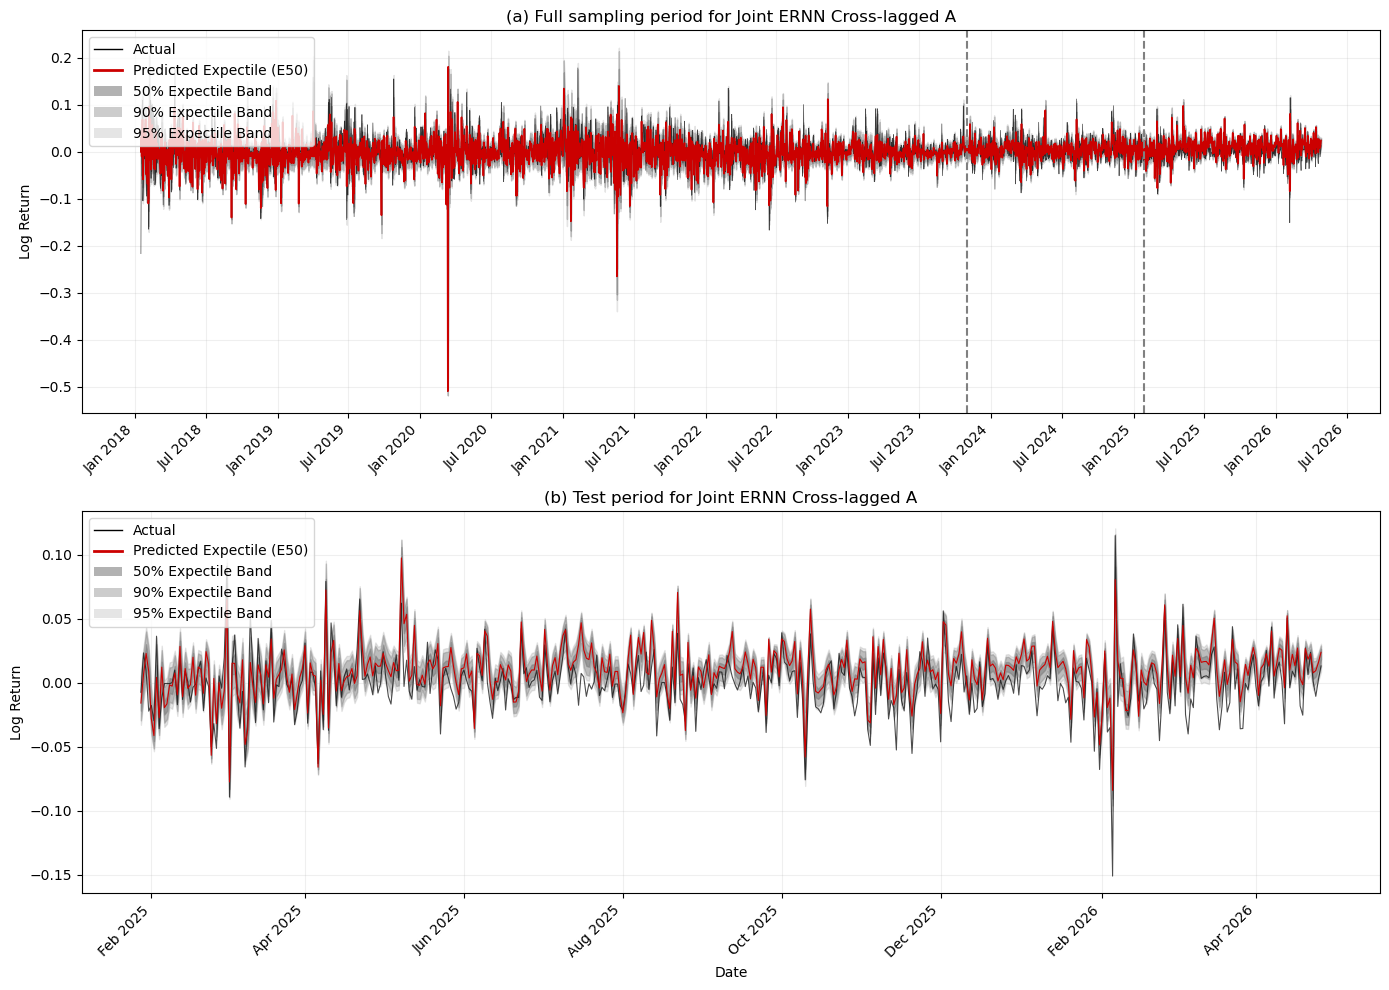

Plot saved to hybrid_ernn_cross_a_joint_predictions.png

TEST METRICS -- JOINT ERNN A CROSS-LAGGED
       tau         NLL        ASE
0.02500000 -2.34064746 0.00004029
0.05000000 -2.39987659 0.00006373
0.25000000 -2.62750101 0.00011632
0.50000000 -2.65807080 0.00013311
0.75000000 -2.70675373 0.00009320
0.95000000 -2.66077638 0.00003086
0.97500000 -2.61350203 0.00001866

Average NLL: -2.572447
Average ASE: 0.00007088

CROSSOVER ANALYSIS -- FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 1 (0.22%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 2 (0.44%) <-- TAIL

Total violations: 3 (0.11%)
Tail violations: 2 (0.22%)

CROSSOVER ANALYSIS -- MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)


In [20]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# Joint ERNN A Self-lagged -- plotting and test evaluation
# Run directly after the ERNN cross-lagged tuning code
# ============================================================

X_test_e = torch.tensor(
    test_df[feature_cols].values,
    dtype=torch.float32
)
y_test_e = torch.tensor(
    test_df['log_return'].values,
    dtype=torch.float32
)

model = best_model_ernn_cross_joint
model.eval()


# -------------------------
# Sequential predictions
# -------------------------
with torch.no_grad():
    e_train, sigma, _, fnn_train = model(
        y_train,
        X_train
    )

    e_val, _, _, fnn_val = model(
        y_val,
        X_val,
        initial_hybrid=e_train[-1],
        initial_y=y_train[-1]
    )

    e_test, _, _, fnn_test = model(
        y_test_e,
        X_test_e,
        initial_hybrid=e_val[-1],
        initial_y=y_val[-1]
    )

e_train_np = e_train.numpy()
e_val_np   = e_val.numpy()
e_test_np  = e_test.numpy()

e_all = np.concatenate(
    [e_train_np, e_val_np, e_test_np],
    axis=0
)

y_all = np.concatenate([
    train_df['log_return'].values,
    val_df['log_return'].values,
    test_df['log_return'].values
])

all_dates = (
    train_df.index
    .append(val_df.index)
    .append(test_df.index)
)

all_preds_ernn_a_cross = {
    tau: e_all[:, k]
    for k, tau in enumerate(tau_levels)
}


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_ernn_joint(
    all_preds,
    train_df,
    val_df,
    test_df,
    save_fname='hybrid_ernn_cross_a_joint_predictions.png'
):
    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    train_size = len(train_df)
    val_size   = len(val_df)
    test_start = train_size + val_size

    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    legend_elements = [
        Line2D(
            [0], [0],
            color=actual_color,
            lw=1,
            label='Actual'
        ),
        Line2D(
            [0], [0],
            color=pred_color,
            lw=2,
            label='Predicted Expectile (E50)'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.6,
            label='50% Expectile Band'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.4,
            label='90% Expectile Band'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.2,
            label='95% Expectile Band'
        )
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10)
    )

    # -------------------------
    # Full sample
    # -------------------------
    ax = axes[0]

    ax.plot(
        all_dates,
        y_all,
        color=actual_color,
        linewidth=0.5,
        alpha=0.7
    )
    ax.plot(
        all_dates,
        all_preds[0.500],
        color=pred_color,
        linewidth=1.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.025],
        all_preds[0.975],
        color=pi_color,
        alpha=0.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.050],
        all_preds[0.950],
        color=pi_color,
        alpha=0.4
    )
    ax.fill_between(
        all_dates,
        all_preds[0.250],
        all_preds[0.750],
        color=pi_color,
        alpha=0.6
    )

    ax.axvline(
        train_df.index[-1],
        color='gray',
        linestyle='--'
    )
    ax.axvline(
        val_df.index[-1],
        color='gray',
        linestyle='--'
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=6)
    )
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_title(
        '(a) Full sampling period for '
        'Joint ERNN Cross-lagged A'
    )
    ax.set_ylabel('Log Return')
    ax.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax.grid(True, alpha=0.2)

    # -------------------------
    # Test sample
    # -------------------------
    ax2 = axes[1]

    ax2.plot(
        test_dates,
        y_test_np,
        color=actual_color,
        linewidth=0.8,
        alpha=0.7
    )
    ax2.plot(
        test_dates,
        all_preds[0.500][test_start:],
        color=pred_color,
        linewidth=0.8
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.025][test_start:],
        all_preds[0.975][test_start:],
        color=pi_color,
        alpha=0.2
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.050][test_start:],
        all_preds[0.950][test_start:],
        color=pi_color,
        alpha=0.4
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.250][test_start:],
        all_preds[0.750][test_start:],
        color=pi_color,
        alpha=0.6
    )

    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax2.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )
    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax2.set_title(
        '(b) Test period for '
        'Joint ERNN Cross-lagged A'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log Return')
    ax2.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        save_fname,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(f'Plot saved to {save_fname}')


plot_two_panel_ernn_joint(
    all_preds_ernn_a_cross,
    train_df,
    val_df,
    test_df
)


# ============================================================
# Test NLL and ASE
# ============================================================
def compute_test_metrics_joint(
    y_test,
    e_test,
    sigma,
    tau_levels
):
    records = []

    for k, tau in enumerate(tau_levels):
        y = y_test
        e = e_test[:, k]
        sigma_k = sigma[k]

        u = y - e
        weight = torch.abs(
            torch.tensor(tau)
            - (u < 0).float()
        )
        omega = weight * u.pow(2)

        constant = (
            np.log(
                np.sqrt(np.pi / tau)
                + np.sqrt(np.pi / (1 - tau))
            )
            - np.log(2.0)
        )

        nll = (
            torch.log(sigma_k)
            + constant
            + omega / sigma_k.pow(2)
        ).mean().item()

        ase = omega.mean().item()

        records.append({
            'tau': tau,
            'NLL': nll,
            'ASE': ase
        })

    results = pd.DataFrame(records)

    print('\n' + '=' * 60)
    print('TEST METRICS -- JOINT ERNN A CROSS-LAGGED')
    print('=' * 60)
    print(
        results.to_string(
            index=False,
            float_format=lambda x: f'{x:.8f}'
        )
    )
    print(f"\nAverage NLL: {results['NLL'].mean():.6f}")
    print(f"Average ASE: {results['ASE'].mean():.8f}")

    results.to_csv(
        'joint_ernn_a_cross_test_metrics.csv',
        index=False
    )

    return results


test_metrics_ernn_a_cross = compute_test_metrics_joint(
    y_test_e,
    e_test,
    sigma,
    tau_levels
)


# ============================================================
# Test crossover analysis
# ============================================================
def compute_crossovers_joint(
    e_pred,
    levels,
    model_name
):
    e = e_pred.numpy()
    T = len(e)

    total_violations = 0
    tail_violations  = 0

    print('\n' + '=' * 60)
    print(f'CROSSOVER ANALYSIS -- {model_name}')
    print('=' * 60)

    for k in range(len(levels) - 1):
        lo = levels[k]
        hi = levels[k + 1]

        violations = int(
            np.sum(e[:, k] > e[:, k + 1])
        )
        percentage = violations / T * 100

        total_violations += violations

        if k == 0 or k == len(levels) - 2:
            tail_violations += violations
            marker = ' <-- TAIL'
        else:
            marker = ''

        print(
            f'({lo:.3f}, {hi:.3f}): '
            f'{violations} ({percentage:.2f}%){marker}'
        )

    total_rate = (
        total_violations /
        (T * (len(levels) - 1))
    )
    tail_rate = tail_violations / (T * 2)

    print(
        f'\nTotal violations: {total_violations} '
        f'({total_rate:.2%})'
    )
    print(
        f'Tail violations: {tail_violations} '
        f'({tail_rate:.2%})'
    )

    return total_violations, tail_violations


# Final hybrid forecasts: crossing may remain
final_crossovers = compute_crossovers_joint(
    e_test,
    tau_levels,
    'FINAL HYBRID OUTPUT'
)

# FNN forecasts: crossing should be zero
fnn_crossovers = compute_crossovers_joint(
    fnn_test,
    tau_levels,
    'MONOTONIC FNN OUTPUT'
)

# Cross over dealing 2

In [23]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Method 2 -- Sequential Hybrid ERNN A Cross-lagged
# ============================================================

m2_ernn_cross_a_tau_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

m2_ernn_cross_a_order = [
    0.500,
    0.750, 0.950, 0.975,
    0.250, 0.050, 0.025
]

m2_ernn_cross_a_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050
}

m2_ernn_cross_a_direction = {
    0.500: 'median',
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower'
}

M2_ERNN_CROSS_A_DELTA = 1e-6
M2_ERNN_CROSS_A_SCALE = 1e-3
M2_ERNN_CROSS_A_PSI_EPS = 1e-4


# ============================================================
# Smooth positive adjustment
# ============================================================

def m2_ernn_cross_a_scaled_softplus(
    value,
    scale=M2_ERNN_CROSS_A_SCALE
):
    return (
        scale
        * F.softplus(value / scale)
    )


# ============================================================
# Method 2 ERNN A cross-lagged model
# ============================================================

class M2SequentialERNNACross(nn.Module):
    def __init__(
        self,
        input_dim,
        config,
        direction='median'
    ):
        super().__init__()

        self.direction = direction
        self.eps = 1e-6

        self.gamma1_raw = nn.Parameter(
            torch.tensor(1.386)
        )

        self.gamma2_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.gamma3_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )

        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        # Nonmedian models receive the adjacent
        # hybrid prediction as an extra input
        fnn_input_dim = (
            input_dim
            if direction == 'median'
            else input_dim + 1
        )

        layers = []
        previous_dim = fnn_input_dim

        for i in range(
            config['n_hidden_layers']
        ):
            hidden_dim = config[
                f'hidden_dim_{i}'
            ]

            layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim
                )
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(
                        config['dropout']
                    )
                )

            previous_dim = hidden_dim

        layers.append(
            nn.Linear(previous_dim, 1)
        )

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(
                        module.weight
                    )

                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(
                        module.weight
                    )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(
        self,
        y,
        X,
        reference=None,
        initial_hybrid=None,
        initial_y=None
    ):
        gamma1 = torch.sigmoid(
            self.gamma1_raw
        )

        gamma2 = F.softplus(
            self.gamma2_raw
        )

        gamma3 = F.softplus(
            self.gamma3_raw
        )

        psi = (
            (1.0 - M2_ERNN_CROSS_A_PSI_EPS)
            * torch.sigmoid(self.psi_raw)
        )

        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        if self.direction == 'median':
            fnn_input = X

        else:
            if reference is None:
                raise ValueError(
                    'A reference prediction is required '
                    'for a nonmedian level.'
                )

            fnn_input = torch.cat(
                [
                    X,
                    reference.reshape(-1, 1)
                ],
                dim=1
            )

        raw_fnn = (
            self.fnn(fnn_input)
            .squeeze(-1)
        )

        (
            e_hybrid,
            e_care,
            constrained_fnn
        ) = m2_ernn_cross_a_location(
            y=y,
            raw_fnn=raw_fnn,
            gamma1=gamma1,
            gamma2=gamma2,
            gamma3=gamma3,
            psi=psi,
            reference=reference,
            direction=self.direction,
            initial_hybrid=initial_hybrid,
            initial_y=initial_y
        )

        return (
            e_hybrid,
            sigma,
            e_care,
            constrained_fnn
        )


# ============================================================
# Cross-lagged asymmetric hybrid location
# ============================================================

def m2_ernn_cross_a_location(
    y,
    raw_fnn,
    gamma1,
    gamma2,
    gamma3,
    psi,
    reference=None,
    direction='median',
    initial_hybrid=None,
    initial_y=None
):
    T = len(y)
    zero = y.new_tensor(0.0)

    hybrid_list = []
    care_list = []
    fnn_list = []

    if (
        (initial_hybrid is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_hybrid and initial_y '
            'must be supplied together.'
        )

    has_initial_state = (
        initial_hybrid is not None
    )

    previous_hybrid = (
        initial_hybrid
        if has_initial_state
        else zero
    )

    for t in range(T):
        if (
            t == 0
            and not has_initial_state
        ):
            hybrid_list.append(zero)
            care_list.append(zero)
            fnn_list.append(raw_fnn[t])
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        y_pos = torch.clamp(
            previous_y,
            min=0
        )

        y_neg = torch.clamp(
            -previous_y,
            min=0
        )

        # Cross-lagged CARE component:
        # use previous final hybrid output
        care_t = (
            gamma1 * previous_hybrid
            + gamma2 * y_pos
            + gamma3 * y_neg
        )

        if direction == 'median':
            fnn_t = raw_fnn[t]

        elif direction == 'upper':
            fnn_lower_bound = (
                reference[t]
                + M2_ERNN_CROSS_A_DELTA
                - psi * care_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_lower_bound
                + m2_ernn_cross_a_scaled_softplus(
                    raw_fnn[t]
                    - fnn_lower_bound
                )
            )

        elif direction == 'lower':
            fnn_upper_bound = (
                reference[t]
                - M2_ERNN_CROSS_A_DELTA
                - psi * care_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_upper_bound
                - m2_ernn_cross_a_scaled_softplus(
                    fnn_upper_bound
                    - raw_fnn[t]
                )
            )

        else:
            raise ValueError(
                "direction must be 'median', "
                "'upper' or 'lower'."
            )

        hybrid_t = (
            psi * care_t
            + (1.0 - psi) * fnn_t
        )

        hybrid_list.append(hybrid_t)
        care_list.append(care_t)
        fnn_list.append(fnn_t)

        # Cross-lagged update
        previous_hybrid = hybrid_t

    return (
        torch.stack(hybrid_list),
        torch.stack(care_list),
        torch.stack(fnn_list)
    )


# ============================================================
# Level-specific AGD loss and ASE
# ============================================================

def m2_ernn_cross_a_loss(
    y,
    e_hybrid,
    sigma,
    tau
):
    residual = y - e_hybrid

    tau_tensor = torch.tensor(
        tau,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    weight = torch.abs(
        tau_tensor
        - (residual < 0).float()
    )

    asymmetric_squared_error = (
        weight
        * residual.pow(2)
    )

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau_tensor
            )
            + torch.sqrt(
                torch.pi
                / (1.0 - tau_tensor)
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma)
        + constant
        + asymmetric_squared_error
        / sigma.pow(2)
    )

    return nll.mean()


def m2_ernn_cross_a_compute_ase(
    y,
    e_hybrid,
    tau
):
    residual = y - e_hybrid

    tau_tensor = torch.tensor(
        tau,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    weight = torch.abs(
        tau_tensor
        - (residual < 0).float()
    )

    return (
        weight
        * residual.pow(2)
    ).mean().item()


# ============================================================
# Optuna configuration
# ============================================================

def m2_ernn_cross_a_suggest_config(
    trial
):
    config = {
        'n_hidden_layers':
            trial.suggest_int(
                'n_hidden_layers',
                1,
                3
            ),
        'activation':
            trial.suggest_categorical(
                'activation',
                [
                    'relu',
                    'elu',
                    'gelu',
                    'tanh'
                ]
            ),
        'dropout':
            trial.suggest_float(
                'dropout',
                0.0,
                0.5
            ),
        'layernorm':
            trial.suggest_categorical(
                'layernorm',
                [True, False]
            ),
        'weight_init':
            trial.suggest_categorical(
                'weight_init',
                ['glorot', 'he']
            ),
        'lr':
            trial.suggest_float(
                'lr',
                1e-4,
                5e-2,
                log=True
            ),
        'optimizer':
            trial.suggest_categorical(
                'optimizer',
                ['adam', 'adamw']
            ),
        'weight_decay':
            trial.suggest_float(
                'weight_decay',
                0.0,
                1e-4
            ),
        'gradient_clip':
            trial.suggest_categorical(
                'gradient_clip',
                [0.1, 1.0, 5.0]
            ),
        'patience':
            trial.suggest_categorical(
                'patience',
                [10, 20, 30]
            )
    }

    for i in range(
        config['n_hidden_layers']
    ):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    return config


# ============================================================
# Fit one expectile level
# ============================================================

def m2_ernn_cross_a_fit(
    config,
    tau,
    direction,
    reference_train=None,
    reference_val=None,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = M2SequentialERNNACross(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        (
            e_train,
            sigma,
            _,
            _
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        train_loss = m2_ernn_cross_a_loss(
            y=y_train[1:],
            e_hybrid=e_train[1:],
            sigma=sigma,
            tau=tau
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():
            (
                e_train_state,
                sigma_val,
                _,
                _
            ) = model(
                y=y_train,
                X=X_train,
                reference=reference_train
            )

            (
                e_val,
                _,
                _,
                _
            ) = model(
                y=y_val,
                X=X_val,
                reference=reference_val,
                initial_hybrid=e_train_state[-1],
                initial_y=y_train[-1]
            )

            val_loss = m2_ernn_cross_a_loss(
                y=y_val,
                e_hybrid=e_val,
                sigma=sigma_val,
                tau=tau
            )

        scheduler.step(
            val_loss.item()
        )

        if (
            val_loss.item()
            < best_val_loss
        ):
            best_val_loss = (
                val_loss.item()
            )

            patience_counter = 0

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


# ============================================================
# Evaluate one level
# ============================================================

def m2_ernn_cross_a_evaluate(
    model,
    tau,
    reference_train=None,
    reference_val=None
):
    model.eval()

    with torch.no_grad():
        (
            e_train,
            sigma,
            care_train,
            fnn_train
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        (
            e_val,
            _,
            care_val,
            fnn_val
        ) = model(
            y=y_val,
            X=X_val,
            reference=reference_val,
            initial_hybrid=e_train[-1],
            initial_y=y_train[-1]
        )

        val_nll = m2_ernn_cross_a_loss(
            y=y_val,
            e_hybrid=e_val,
            sigma=sigma,
            tau=tau
        ).item()

        val_ase = (
            m2_ernn_cross_a_compute_ase(
                y=y_val,
                e_hybrid=e_val,
                tau=tau
            )
        )

        gamma1 = torch.sigmoid(
            model.gamma1_raw
        ).item()

        gamma2 = F.softplus(
            model.gamma2_raw
        ).item()

        gamma3 = F.softplus(
            model.gamma3_raw
        ).item()

        psi = (
            (1.0 - M2_ERNN_CROSS_A_PSI_EPS)
            * torch.sigmoid(model.psi_raw)
        ).item()

        sigma_value = (
            F.softplus(model.sigma_raw)
            + model.eps
        ).item()

    return {
        'val_nll': val_nll,
        'val_ase': val_ase,
        'train_prediction':
            e_train.detach(),
        'val_prediction':
            e_val.detach(),
        'train_care':
            care_train.detach(),
        'val_care':
            care_val.detach(),
        'train_fnn':
            fnn_train.detach(),
        'val_fnn':
            fnn_val.detach(),
        'gamma1': gamma1,
        'gamma2': gamma2,
        'gamma3': gamma3,
        'psi': psi,
        'sigma': sigma_value
    }


# ============================================================
# Objective factory
# ============================================================

def m2_ernn_cross_a_make_objective(
    tau,
    direction,
    reference_train,
    reference_val,
    seed
):
    def objective(trial):
        config = (
            m2_ernn_cross_a_suggest_config(
                trial
            )
        )

        model = m2_ernn_cross_a_fit(
            config=config,
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=seed
        )

        if model is None:
            return float('inf')

        metrics = (
            m2_ernn_cross_a_evaluate(
                model=model,
                tau=tau,
                reference_train=reference_train,
                reference_val=reference_val
            )
        )

        trial.set_user_attr(
            'val_nll',
            metrics['val_nll']
        )

        trial.set_user_attr(
            'val_ase',
            metrics['val_ase']
        )

        for parameter in [
            'gamma1',
            'gamma2',
            'gamma3',
            'psi',
            'sigma'
        ]:
            trial.set_user_attr(
                parameter,
                metrics[parameter]
            )

        print(
            f"Trial {trial.number}: "
            f"tau={tau:.3f} | "
            f"NLL={metrics['val_nll']:.6f} | "
            f"ASE={metrics['val_ase']:.8f}"
        )

        return metrics['val_nll']

    return objective


# ============================================================
# Rank by validation NLL and ASE
# ============================================================

def m2_ernn_cross_a_select_trial(
    study
):
    trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and 'val_nll'
            in trial.user_attrs
            and 'val_ase'
            in trial.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for trial in trials:
        trial._nll = (
            trial.user_attrs['val_nll']
        )

        trial._ase = (
            trial.user_attrs['val_ase']
        )

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._nll
        ),
        start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._ase
        ),
        start=1
    ):
        trial._rank_ase = rank

    best_trial = min(
        trials,
        key=lambda item: (
            item._rank_nll
            + item._rank_ase,
            item._nll,
            item._ase,
            item.number
        )
    )

    return best_trial, trials


# ============================================================
# Sequential tuning
# ============================================================

m2_ernn_cross_a_best_configs = {}
m2_ernn_cross_a_final_models = {}
m2_ernn_cross_a_train_predictions = {}
m2_ernn_cross_a_val_predictions = {}
m2_ernn_cross_a_validation_metrics = {}
m2_ernn_cross_a_studies = {}

for level_index, tau in enumerate(
    m2_ernn_cross_a_order
):
    direction = (
        m2_ernn_cross_a_direction[tau]
    )

    reference_tau = (
        m2_ernn_cross_a_reference[tau]
    )

    if reference_tau is None:
        reference_train = None
        reference_val = None

    else:
        reference_train = (
            m2_ernn_cross_a_train_predictions[
                reference_tau
            ].detach()
        )

        reference_val = (
            m2_ernn_cross_a_val_predictions[
                reference_tau
            ].detach()
        )

    current_seed = 2026 + level_index

    print('\n' + '=' * 70)
    print(
        'METHOD 2 -- TUNING ERNN A CROSS-LAGGED '
        f'FOR TAU = {tau}'
    )
    print(
        f'Direction: {direction} | '
        f'Reference: {reference_tau}'
    )
    print('=' * 70)

    sampler = TPESampler(
        seed=current_seed
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=sampler
    )

    objective = (
        m2_ernn_cross_a_make_objective(
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            seed=current_seed
        )
    )

    study.optimize(
        objective,
        n_trials=200,
        show_progress_bar=True
    )

    (
        best_trial,
        valid_trials
    ) = m2_ernn_cross_a_select_trial(
        study
    )

    # Save ranking for this level
    ranking_records = []

    for trial in valid_trials:
        record = {
            'tau': tau,
            'trial': trial.number,
            'val_nll': trial._nll,
            'val_ase': trial._ase,
            'rank_nll':
                trial._rank_nll,
            'rank_ase':
                trial._rank_ase,
            'sum_rank':
                trial._rank_nll
                + trial._rank_ase,
            'gamma1':
                trial.user_attrs['gamma1'],
            'gamma2':
                trial.user_attrs['gamma2'],
            'gamma3':
                trial.user_attrs['gamma3'],
            'psi':
                trial.user_attrs['psi'],
            'sigma':
                trial.user_attrs['sigma']
        }

        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(
        ranking_records
    ).sort_values(
        [
            'sum_rank',
            'val_nll',
            'val_ase'
        ]
    )

    ranking_df.to_csv(
        (
            'method2_sequential_ernn_a_cross_'
            f'ranking_tau_{tau}.csv'
        ),
        index=False
    )

    best_config = (
        best_trial.params.copy()
    )

    # Refit selected architecture
    final_model = (
        m2_ernn_cross_a_fit(
            config=best_config,
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=current_seed
        )
    )

    final_metrics = (
        m2_ernn_cross_a_evaluate(
            model=final_model,
            tau=tau,
            reference_train=reference_train,
            reference_val=reference_val
        )
    )

    m2_ernn_cross_a_best_configs[
        tau
    ] = best_config

    m2_ernn_cross_a_final_models[
        tau
    ] = final_model

    m2_ernn_cross_a_train_predictions[
        tau
    ] = final_metrics[
        'train_prediction'
    ]

    m2_ernn_cross_a_val_predictions[
        tau
    ] = final_metrics[
        'val_prediction'
    ]

    m2_ernn_cross_a_validation_metrics[
        tau
    ] = {
        'val_nll':
            final_metrics['val_nll'],
        'val_ase':
            final_metrics['val_ase'],
        'gamma1':
            final_metrics['gamma1'],
        'gamma2':
            final_metrics['gamma2'],
        'gamma3':
            final_metrics['gamma3'],
        'psi':
            final_metrics['psi'],
        'sigma':
            final_metrics['sigma'],
        'direction':
            direction,
        'reference_tau':
            reference_tau,
        'best_trial':
            best_trial.number
    }

    m2_ernn_cross_a_studies[
        tau
    ] = study

    print(
        f'\nSelected tau={tau:.3f}: '
        f"NLL={final_metrics['val_nll']:.6f} | "
        f"ASE={final_metrics['val_ase']:.8f}"
    )


# ============================================================
# Validation crossover check
# ============================================================

m2_ernn_cross_a_val_matrix = torch.stack(
    [
        m2_ernn_cross_a_val_predictions[tau]
        for tau
        in m2_ernn_cross_a_tau_levels
    ],
    dim=1
)

m2_ernn_cross_a_val_crossovers = (
    m2_ernn_cross_a_val_matrix[:, :-1]
    > m2_ernn_cross_a_val_matrix[:, 1:]
)

m2_ernn_cross_a_val_pair_counts = (
    m2_ernn_cross_a_val_crossovers
    .sum(dim=0)
)

m2_ernn_cross_a_val_total_crossovers = int(
    m2_ernn_cross_a_val_pair_counts
    .sum()
    .item()
)

m2_ernn_cross_a_val_tail_crossovers = int(
    (
        m2_ernn_cross_a_val_pair_counts[0]
        + m2_ernn_cross_a_val_pair_counts[-1]
    ).item()
)


# ============================================================
# Save all seven models
# ============================================================

m2_ernn_cross_a_saved_models = {}

for tau in m2_ernn_cross_a_tau_levels:
    m2_ernn_cross_a_saved_models[
        str(tau)
    ] = {
        'state_dict':
            m2_ernn_cross_a_final_models[
                tau
            ].state_dict(),
        'config':
            m2_ernn_cross_a_best_configs[
                tau
            ],
        'direction':
            m2_ernn_cross_a_direction[
                tau
            ],
        'reference_tau':
            m2_ernn_cross_a_reference[
                tau
            ]
    }

torch.save(
    {
        'tau_levels':
            m2_ernn_cross_a_tau_levels,
        'estimation_order':
            m2_ernn_cross_a_order,
        'models':
            m2_ernn_cross_a_saved_models,
        'validation_metrics':
            m2_ernn_cross_a_validation_metrics,
        'validation_crossover_count':
            m2_ernn_cross_a_val_total_crossovers,
        'validation_tail_count':
            m2_ernn_cross_a_val_tail_crossovers,
        'delta':
            M2_ERNN_CROSS_A_DELTA,
        'softplus_scale':
            M2_ERNN_CROSS_A_SCALE
    },
    'method2_sequential_ernn_a_cross_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

m2_ernn_cross_a_average_val_nll = np.mean(
    [
        m2_ernn_cross_a_validation_metrics[
            tau
        ]['val_nll']
        for tau
        in m2_ernn_cross_a_tau_levels
    ]
)

m2_ernn_cross_a_average_val_ase = np.mean(
    [
        m2_ernn_cross_a_validation_metrics[
            tau
        ]['val_ase']
        for tau
        in m2_ernn_cross_a_tau_levels
    ]
)

print('\n' + '=' * 70)
print(
    'METHOD 2 TUNING COMPLETE -- '
    'ERNN A CROSS-LAGGED'
)
print('=' * 70)

print(
    f'Average validation NLL: '
    f'{m2_ernn_cross_a_average_val_nll:.6f}'
)

print(
    f'Average validation ASE: '
    f'{m2_ernn_cross_a_average_val_ase:.8f}'
)

print(
    f'Validation crossover count: '
    f'{m2_ernn_cross_a_val_total_crossovers}'
)

print(
    f'Validation tail crossover count: '
    f'{m2_ernn_cross_a_val_tail_crossovers}'
)

print(
    'Checkpoint saved to '
    'method2_sequential_ernn_a_cross_best.pt'
)

[I 2026-08-03 13:44:26,572] A new study created in memory with name: no-name-951263ea-c453-4045-b6fb-12655f5f810c



METHOD 2 -- TUNING ERNN A CROSS-LAGGED FOR TAU = 0.5
Direction: median | Reference: None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.500 | NLL=0.801021 | ASE=0.00256676
[I 2026-08-03 13:44:50,863] Trial 0 finished with value: 0.8010214567184448 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8010214567184448.
Trial 1: tau=0.500 | NLL=-0.232307 | ASE=0.00036769
[I 2026-08-03 13:45:19,961] Trial 1 finished with value: -0.23230735957622528 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.23230735957622528.
Trial 2: tau=0.500 | NLL=0.906290 | ASE=0.01309824
[I 2026-08-03 13:45:24,200] Tri

[I 2026-08-03 15:04:27,420] A new study created in memory with name: no-name-b51365ad-b02d-4d90-bb97-de8045ce0219


...

Trial 0: tau=0.050 | NLL=0.504401 | ASE=0.00008698
[I 2026-08-04 11:10:56,967] Trial 0 finished with value: 0.5044013857841492 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.5044013857841492.
Trial 1: tau=0.050 | NLL=-0.769266 | ASE=0.00008555
[I 2026-08-04 11:11:44,165] Trial 1 finished with value: -0.7692658305168152 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7692658305168152.
Trial 2: tau=0.050

[I 2026-08-04 14:28:44,107] A new study created in memory with name: no-name-19c3be10-d51c-4708-b74f-37724c404329



Selected tau=0.050: NLL=-2.068063 | ASE=0.00010589

METHOD 2 -- TUNING ERNN A CROSS-LAGGED FOR TAU = 0.025
Direction: lower | Reference: 0.05


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.025 | NLL=0.645645 | ASE=0.00006853
[I 2026-08-04 14:29:29,562] Trial 0 finished with value: 0.6456447839736938 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6456447839736938.
Trial 1: tau=0.025 | NLL=1.552227 | ASE=0.00006853
[I 2026-08-04 14:30:16,272] Trial 1 finished with value: 1.5522270202636719 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6456447839736938.
T

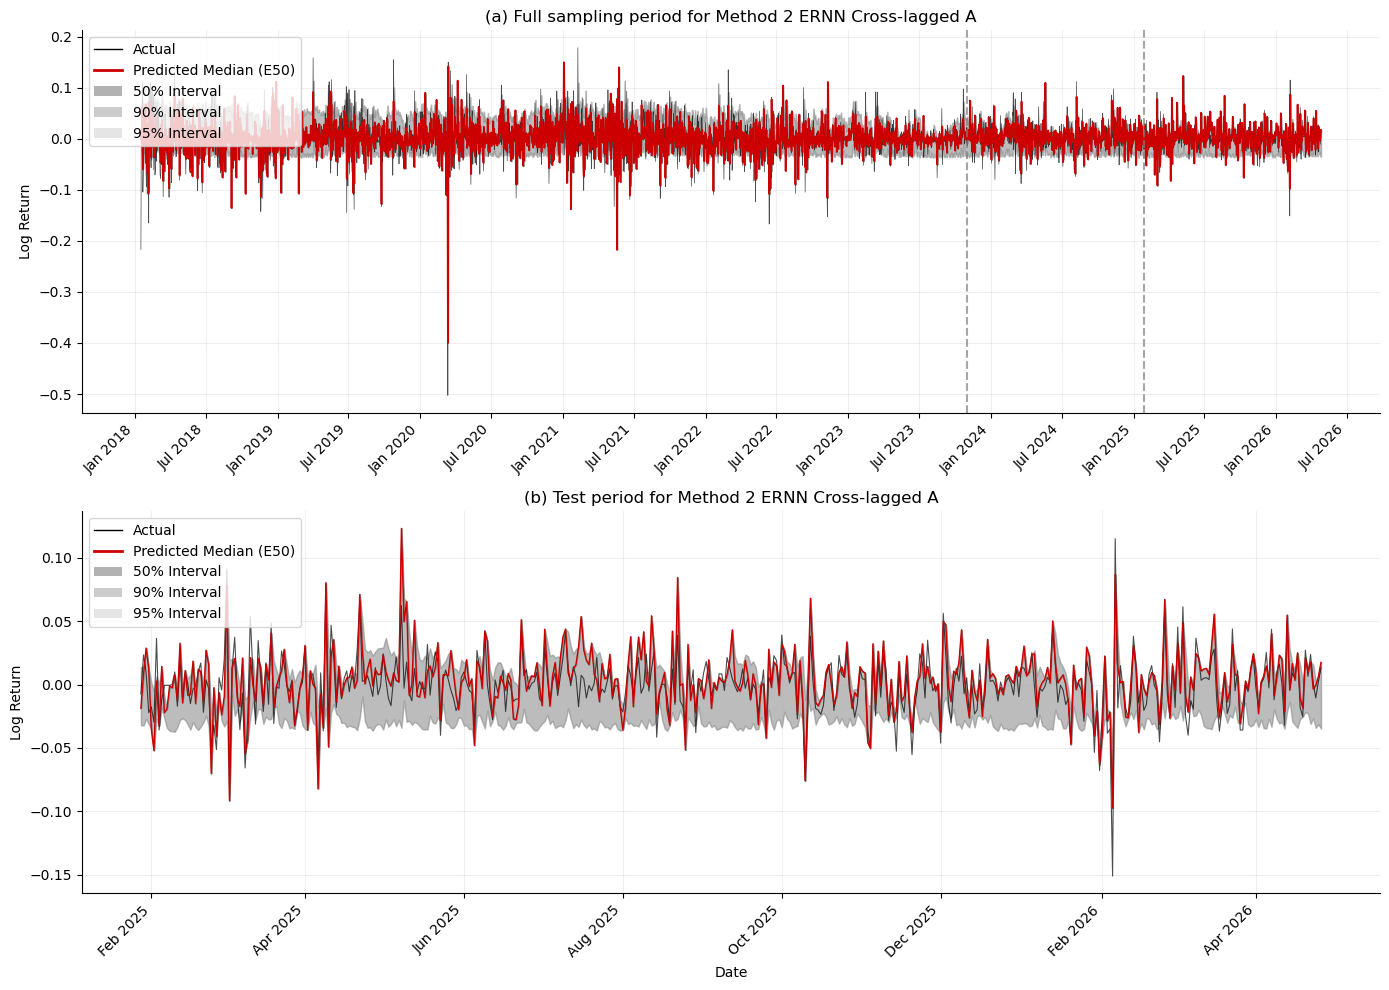

Plot saved to method2_sequential_ernn_a_cross_predictions.png

TEST METRICS -- METHOD 2 ERNN A CROSS-LAGGED
  tau       NLL      ASE
0.025 -2.187999 0.000049
0.050 -2.132757 0.000081
0.250 -2.606042 0.000126
0.500 -2.720008 0.000099
0.750 -2.777318 0.000073
0.950 -2.318505 0.000047
0.975 -2.196761 0.000036

Average NLL: -2.419913
Average ASE: 0.00007298

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

Metrics saved to method2_sequential_ernn_a_cross_test_metrics.csv


In [25]:
# ============================================================
# Plot and evaluate Method 2
# Sequential ERNN A Cross-lagged
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# Generate full-sample predictions sequentially
# ============================================================

m2_ernn_cross_a_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

m2_ernn_cross_a_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)

m2_ernn_cross_a_all_predictions = {}
m2_ernn_cross_a_all_care = {}
m2_ernn_cross_a_all_fnn = {}
m2_ernn_cross_a_all_sigma = {}

for tau in m2_ernn_cross_a_order:
    model = m2_ernn_cross_a_final_models[tau]

    reference_tau = (
        m2_ernn_cross_a_reference[tau]
    )

    if reference_tau is None:
        reference_prediction = None
    else:
        reference_prediction = (
            m2_ernn_cross_a_all_predictions[
                reference_tau
            ]
        )

    model.eval()

    with torch.no_grad():
        (
            prediction,
            sigma,
            care_output,
            fnn_output
        ) = model(
            y=m2_ernn_cross_a_y_all,
            X=m2_ernn_cross_a_X_all,
            reference=reference_prediction
        )

    m2_ernn_cross_a_all_predictions[
        tau
    ] = prediction.detach()

    m2_ernn_cross_a_all_care[
        tau
    ] = care_output.detach()

    m2_ernn_cross_a_all_fnn[
        tau
    ] = fnn_output.detach()

    m2_ernn_cross_a_all_sigma[
        tau
    ] = sigma.detach()


m2_ernn_cross_a_all_preds_np = {
    tau: prediction.cpu().numpy()
    for tau, prediction
    in m2_ernn_cross_a_all_predictions.items()
}


# ============================================================
# Sample information
# ============================================================

m2_ernn_cross_a_train_size = len(
    train_df
)

m2_ernn_cross_a_val_size = len(
    val_df
)

m2_ernn_cross_a_test_start = (
    m2_ernn_cross_a_train_size
    + m2_ernn_cross_a_val_size
)

m2_ernn_cross_a_all_dates = df.index
m2_ernn_cross_a_test_dates = test_df.index

m2_ernn_cross_a_y_all_np = (
    df['log_return'].values
)

m2_ernn_cross_a_y_test_np = (
    test_df['log_return'].values
)


# ============================================================
# Plot
# ============================================================

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'

legend_elements = [
    Line2D(
        [0], [0],
        color=actual_color,
        linewidth=1,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=median_color,
        linewidth=2,
        label='Predicted Median (E50)'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.60,
        label='50% Interval'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.40,
        label='90% Interval'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.20,
        label='95% Interval'
    )
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)


# Full sample
ax = axes[0]

ax.plot(
    m2_ernn_cross_a_all_dates,
    m2_ernn_cross_a_y_all_np,
    color=actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    m2_ernn_cross_a_all_dates,
    m2_ernn_cross_a_all_preds_np[0.500],
    color=median_color,
    linewidth=1.2
)

ax.fill_between(
    m2_ernn_cross_a_all_dates,
    m2_ernn_cross_a_all_preds_np[0.025],
    m2_ernn_cross_a_all_preds_np[0.975],
    color=interval_color,
    alpha=0.20
)

ax.fill_between(
    m2_ernn_cross_a_all_dates,
    m2_ernn_cross_a_all_preds_np[0.050],
    m2_ernn_cross_a_all_preds_np[0.950],
    color=interval_color,
    alpha=0.40
)

ax.fill_between(
    m2_ernn_cross_a_all_dates,
    m2_ernn_cross_a_all_preds_np[0.250],
    m2_ernn_cross_a_all_preds_np[0.750],
    color=interval_color,
    alpha=0.60
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

ax.set_title(
    '(a) Full sampling period for '
    'Method 2 ERNN Cross-lagged A'
)

ax.set_ylabel('Log Return')
ax.grid(True, alpha=0.2)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

ax.legend(
    handles=legend_elements,
    loc='upper left'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Test sample
ax2 = axes[1]

ax2.plot(
    m2_ernn_cross_a_test_dates,
    m2_ernn_cross_a_y_test_np,
    color=actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    m2_ernn_cross_a_test_dates,
    m2_ernn_cross_a_all_preds_np[0.500][
        m2_ernn_cross_a_test_start:
    ],
    color=median_color,
    linewidth=1.0
)

ax2.fill_between(
    m2_ernn_cross_a_test_dates,
    m2_ernn_cross_a_all_preds_np[0.025][
        m2_ernn_cross_a_test_start:
    ],
    m2_ernn_cross_a_all_preds_np[0.975][
        m2_ernn_cross_a_test_start:
    ],
    color=interval_color,
    alpha=0.20
)

ax2.fill_between(
    m2_ernn_cross_a_test_dates,
    m2_ernn_cross_a_all_preds_np[0.050][
        m2_ernn_cross_a_test_start:
    ],
    m2_ernn_cross_a_all_preds_np[0.950][
        m2_ernn_cross_a_test_start:
    ],
    color=interval_color,
    alpha=0.40
)

ax2.fill_between(
    m2_ernn_cross_a_test_dates,
    m2_ernn_cross_a_all_preds_np[0.250][
        m2_ernn_cross_a_test_start:
    ],
    m2_ernn_cross_a_all_preds_np[0.750][
        m2_ernn_cross_a_test_start:
    ],
    color=interval_color,
    alpha=0.60
)

ax2.set_title(
    '(b) Test period for '
    'Method 2 ERNN Cross-lagged A'
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.grid(True, alpha=0.2)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax2.legend(
    handles=legend_elements,
    loc='upper left'
)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for axis in axes:
    plt.setp(
        axis.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

plt.tight_layout()

m2_ernn_cross_a_plot_name = (
    'method2_sequential_ernn_a_cross_predictions.png'
)

plt.savefig(
    m2_ernn_cross_a_plot_name,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(
    f'Plot saved to '
    f'{m2_ernn_cross_a_plot_name}'
)


# ============================================================
# Test metrics
# ============================================================

m2_ernn_cross_a_y_test = (
    m2_ernn_cross_a_y_all[
        m2_ernn_cross_a_test_start:
    ]
)

m2_ernn_cross_a_metric_rows = []

for tau in m2_ernn_cross_a_tau_levels:
    test_prediction = (
        m2_ernn_cross_a_all_predictions[
            tau
        ][m2_ernn_cross_a_test_start:]
    )

    sigma = (
        m2_ernn_cross_a_all_sigma[tau]
    )

    test_nll = (
        m2_ernn_cross_a_loss(
            y=m2_ernn_cross_a_y_test,
            e_hybrid=test_prediction,
            sigma=sigma,
            tau=tau
        ).item()
    )

    test_ase = (
        m2_ernn_cross_a_compute_ase(
            y=m2_ernn_cross_a_y_test,
            e_hybrid=test_prediction,
            tau=tau
        )
    )

    m2_ernn_cross_a_metric_rows.append({
        'tau': tau,
        'NLL': test_nll,
        'ASE': test_ase
    })


m2_ernn_cross_a_metrics_df = pd.DataFrame(
    m2_ernn_cross_a_metric_rows
)

m2_ernn_cross_a_average_nll = (
    m2_ernn_cross_a_metrics_df[
        'NLL'
    ].mean()
)

m2_ernn_cross_a_average_ase = (
    m2_ernn_cross_a_metrics_df[
        'ASE'
    ].mean()
)

print('\n' + '=' * 68)
print(
    'TEST METRICS -- METHOD 2 '
    'ERNN A CROSS-LAGGED'
)
print('=' * 68)

print(
    m2_ernn_cross_a_metrics_df.to_string(
        index=False
    )
)

print(
    f'\nAverage NLL: '
    f'{m2_ernn_cross_a_average_nll:.6f}'
)

print(
    f'Average ASE: '
    f'{m2_ernn_cross_a_average_ase:.8f}'
)


# ============================================================
# Crossover analysis
# ============================================================

m2_ernn_cross_a_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975)
]

m2_ernn_cross_a_tail_pairs = [
    (0.025, 0.050),
    (0.950, 0.975)
]

m2_ernn_cross_a_total_crossovers = 0
m2_ernn_cross_a_tail_crossovers = 0
m2_ernn_cross_a_crossover_rows = []

print('\n' + '=' * 68)
print(
    'CROSSOVER ANALYSIS -- '
    'FINAL METHOD 2 HYBRID OUTPUT'
)
print('=' * 68)

for lower_tau, upper_tau in (
    m2_ernn_cross_a_pairs
):
    lower_prediction = (
        m2_ernn_cross_a_all_predictions[
            lower_tau
        ][m2_ernn_cross_a_test_start:]
    )

    upper_prediction = (
        m2_ernn_cross_a_all_predictions[
            upper_tau
        ][m2_ernn_cross_a_test_start:]
    )

    violations = int(
        (
            lower_prediction
            > upper_prediction
        ).sum().item()
    )

    rate = (
        violations
        / len(lower_prediction)
    )

    m2_ernn_cross_a_total_crossovers += (
        violations
    )

    if (
        lower_tau,
        upper_tau
    ) in m2_ernn_cross_a_tail_pairs:
        m2_ernn_cross_a_tail_crossovers += (
            violations
        )

    m2_ernn_cross_a_crossover_rows.append({
        'Lower': lower_tau,
        'Upper': upper_tau,
        'Violations': violations,
        'Rate': rate
    })

    tail_label = (
        ' <-- TAIL'
        if (
            lower_tau,
            upper_tau
        ) in m2_ernn_cross_a_tail_pairs
        else ''
    )

    print(
        f'({lower_tau:.3f}, '
        f'{upper_tau:.3f}): '
        f'{violations} '
        f'({100 * rate:.2f}%)'
        f'{tail_label}'
    )


m2_ernn_cross_a_total_rate = (
    m2_ernn_cross_a_total_crossovers
    / (
        len(m2_ernn_cross_a_y_test)
        * 6
    )
)

m2_ernn_cross_a_tail_rate = (
    m2_ernn_cross_a_tail_crossovers
    / (
        len(m2_ernn_cross_a_y_test)
        * 2
    )
)

print(
    f'\nTotal violations: '
    f'{m2_ernn_cross_a_total_crossovers} '
    f'({100 * m2_ernn_cross_a_total_rate:.2f}%)'
)

print(
    f'Tail violations: '
    f'{m2_ernn_cross_a_tail_crossovers} '
    f'({100 * m2_ernn_cross_a_tail_rate:.2f}%)'
)


# ============================================================
# Save metrics
# ============================================================

m2_ernn_cross_a_metrics_df.to_csv(
    (
        'method2_sequential_ernn_a_cross_'
        'test_metrics.csv'
    ),
    index=False
)

pd.DataFrame(
    m2_ernn_cross_a_crossover_rows
).to_csv(
    (
        'method2_sequential_ernn_a_cross_'
        'crossover.csv'
    ),
    index=False
)

print(
    '\nMetrics saved to '
    'method2_sequential_ernn_a_cross_'
    'test_metrics.csv'
)

# Crossover dealing 3

In [28]:
"""Method 3, Specification 1: Hybrid ERNN A cross-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_ernn_a_cross_results")

# This standalone chunk estimates only the model supplied by the user:
# Hybrid ERNN, asymmetric form, cross-lagged recursion.
MODELS_TO_RUN = [("ernn", "a", "cross")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_ernn_a_cross_validation_summary.csv", index=False
        )
    print("\nMethod 3 ERNN A cross-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-16 14:23:34,895] A new study created in memory with name: no-name-96d25e31-5110-4d5c-88e2-979d53b02815



METHOD 3 SPACING: ERNN A CROSS
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 14:24:05,089] Trial 0 finished with value: 0.8010214567184448 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8010214567184448.
[I 2026-08-16 14:24:33,534] Trial 1 finished with value: -0.23230735957622528 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.23230735957622528.
[I 2026-08-16 14:24:36,788] Trial 2 finished with value: 0.9062902927398682 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': Tru

[I 2026-08-16 16:28:33,548] A new study created in memory with name: no-name-53dd9163-3fef-44a0-a713-3b22293e54c1


...

[I 2026-08-16 17:17:03,370] Trial 0 finished with value: 0.5041031241416931 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.5041031241416931.
[I 2026-08-16 17:17:09,371] Trial 1 finished with value: -0.7731963992118835 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7731963992118835.
[I 2026-08-16 17:17:13,020] Trial 2 finished with value: 1.4520803689956665 and parameters: {'n_hidden_layers': 2, 'activ

[I 2026-08-16 17:27:46,561] A new study created in memory with name: no-name-d66967e6-bbae-4003-8a4c-5236616d21e8


Selected trial #101 | val NLL=-2.533969 | calibration=0.000048 | mean delta=0.012181
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 17:27:52,531] Trial 0 finished with value: 0.6449386477470398 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6449386477470398.
[I 2026-08-16 17:27:58,340] Trial 1 finished with value: 1.552208423614502 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6449386477470398.
[I 2026-08-16 17:28:00,813] Trial 2 finished with value: 1.6965984106063843 and parameters: {'n_hidden_l

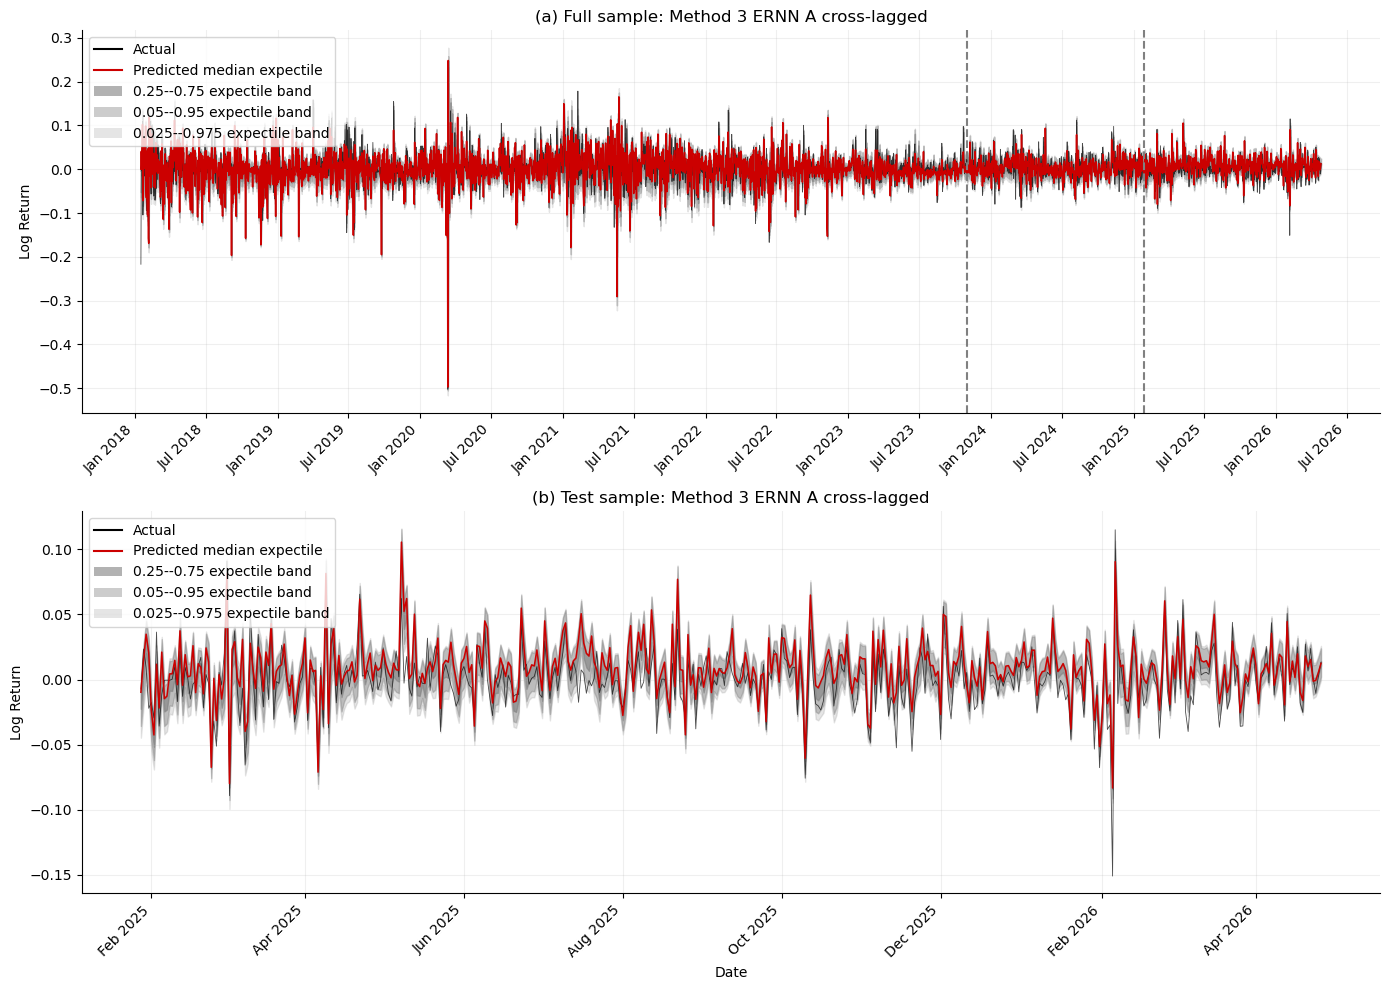


METHOD 3 ERNN A SELF-LAGGED -- TEST RESULTS
                model  test_T  average_nll  average_ase  crossover  tail
Method 3 ERNN A Cross     454    -2.692515     0.000057          0     0

Per-level results:
  tau       nll      ase    sigma
0.025 -2.528816 0.000026 0.008704
0.050 -2.615404 0.000040 0.010401
0.250 -2.723235 0.000090 0.017539
0.500 -2.612128 0.000124 0.023305
0.750 -2.823652 0.000073 0.015953
0.950 -2.773672 0.000029 0.008717
0.975 -2.770695 0.000016 0.006662

Learned-spacing diagnostics:
  tau  reference_tau direction  mean_delta    min_delta  max_delta  sd_delta  near_zero_count  near_zero_rate
0.025           0.05     lower    0.004431 2.055632e-03   0.009775  0.001648                0          0.0000
0.050           0.25     lower    0.009487 5.650905e-03   0.016963  0.001778                0          0.0000
0.250           0.50     lower    0.007733 8.030532e-04   0.016092  0.004164                0          0.0000
0.750           0.50     upper    0.000287 1.25

In [30]:
"""Plot and evaluate Method 3 ERNN A cross-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

RESULT_DIR = Path("method3_spacing_ernn_a_cross_results")
MODEL_DIR = RESULT_DIR / "ernn_a_cross"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_ernn_a_cross_best.pt"
PLOT_PATH = MODEL_DIR / "method3_spacing_ernn_a_cross.png"
METRICS_PATH = MODEL_DIR / "method3_spacing_ernn_a_cross_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "method3_spacing_ernn_a_cross_test_summary.csv"
DELTA_PATH = MODEL_DIR / "method3_spacing_ernn_a_cross_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "method3_spacing_ernn_a_cross_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    from method3_spacing_ernn_a_cross_tuning import Method3SpacingModel

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "ernn":
    raise ValueError("The checkpoint is not an ERNN checkpoint.")
if checkpoint.get("form") != "a" or checkpoint.get("lag") != "cross":
    raise ValueError("The checkpoint is not the ERNN A cross-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="ernn",
        form="a",
        lag="cross",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 ERNN A cross-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 ERNN A cross-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median expectile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 expectile band"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 expectile band"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 expectile band"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test AGD NLL and asymmetric squared error
# ---------------------------------------------------------------------------


def agd_nll(y, expectile, sigma, tau):
    residual = y - expectile
    tau_tensor = torch.tensor(tau, dtype=y.dtype, device=y.device)
    weight = torch.abs(tau_tensor - (residual < 0).to(y.dtype))
    constant = (
        torch.log(
            torch.sqrt(torch.pi / tau_tensor)
            + torch.sqrt(torch.pi / (1.0 - tau_tensor))
        )
        - np.log(2.0)
    )
    return (
        torch.log(sigma)
        + constant
        + weight * residual.square() / sigma.square()
    ).mean()


def asymmetric_squared_error(y, expectile, tau):
    residual = y - expectile
    weight = torch.where(
        residual >= 0,
        torch.full_like(residual, tau),
        torch.full_like(residual, 1.0 - tau),
    )
    return (weight * residual.square()).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    metric_rows.append({
        "tau": level,
        "nll": agd_nll(y_test, prediction_test, sigmas[level], level).item(),
        "ase": asymmetric_squared_error(y_test, prediction_test, level).item(),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "tau": level,
        "reference_tau": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 ERNN A Cross",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_ase": metrics_df["ase"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"e_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 ERNN A SELF-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")